# Portfolio Backtesting Pipeline
**Dataset:** CRSP/Compustat monthly factor panel  
**Universe:** User-selected PERMNOs  
**Rebalancing:** Monthly, constant target weights  
**Return metric:** `ret` — raw monthly holding-period return (decimal)

In [23]:
# ── 0. Dependencies ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#0f0f1a',
    'axes.edgecolor':   '#333355',
    'axes.labelcolor':  '#ccccee',
    'xtick.color':      '#888899',
    'ytick.color':      '#888899',
    'text.color':       '#ccccee',
    'grid.color':       '#1e1e30',
    'grid.linestyle':   '--',
    'font.family':      'monospace',
    'figure.dpi':       130,
})
ACCENT   = ['#7b9dff','#ff7b9d','#7bffcb','#ffcb7b','#cb7bff',
             '#ff9d7b','#9dff7b','#7bcbff','#ffff7b','#ff7bff']
print('Dependencies loaded.')

Dependencies loaded.


### 1. Configuration 
Note: we have the freedom to change the selected stocks and weights here, and many other parameters. If we want to add more combatibility features or restrictions, please do so here. 

In [24]:
# ── 1. Configuration — EDIT THIS CELL ──────────────────────────────────────────
DATA_PATH = r'C:\Users\dream\OneDrive\文档\GitHub\ml-alpha-ranking-portfolio\backtesting\dataset.csv'

# --- 10 stocks by PERMNO ---
# Replace with any PERMNOs present in your dataset.
# To explore available PERMNOs run the helper cell below.
SELECTED_PERMNOS = [10078, 10107, 10138, 10145, 10150,
                    10200, 10232, 10252, 10294, 10333]

# --- Portfolio weights (must sum to 1.0) ---
# Equal-weight default. Change to any convex combination.
WEIGHTS = np.array([0.10, 0.10, 0.10, 0.10, 0.10,
                    0.10, 0.10, 0.10, 0.10, 0.10])
assert len(WEIGHTS) == len(SELECTED_PERMNOS), "weights / permnos length mismatch"
assert abs(WEIGHTS.sum() - 1.0) < 1e-8, f"weights sum to {WEIGHTS.sum():.6f}, not 1.0"

# --- Date range (YYYYMM integers) ---
START_YYYYMM = 199601   # inclusive
END_YYYYMM   = 202412   # inclusive — hard cap at Dec-2024

# --- Annualised risk-free rate used for Sharpe calculation ---
# 0.04 = 4 % p.a. proxy (approx. US T-bill long-run avg).
# Switch to 0.0 for excess-return Sharpe == Information Ratio over zero.
ANNUAL_RF = 0.04 #TODO: why, and is there a better RF? monthly RF? 
MONTHLY_RF = (1 + ANNUAL_RF) ** (1/12) - 1

print(f'Config OK | {len(SELECTED_PERMNOS)} stocks | weights sum = {WEIGHTS.sum()}')

Config OK | 10 stocks | weights sum = 1.0


In [25]:
# ── 2. Load data (chunked for large files) ─────────────────────────────────────
print('Loading dataset … (this may take ~30–60 s for a 300 MB file)')

COLS = ['permno', 'yyyymm', 'ret']

chunks = []
for chunk in pd.read_csv(
        DATA_PATH,
        usecols=COLS,
        dtype={'permno': np.int32, 'yyyymm': np.int32, 'ret': np.float32},
        chunksize=500_000,
):
    # Pre-filter inside each chunk to keep RAM low
    mask = (
        chunk['permno'].isin(SELECTED_PERMNOS) &
        (chunk['yyyymm'] >= START_YYYYMM) &
        (chunk['yyyymm'] <= END_YYYYMM)
    )
    chunks.append(chunk.loc[mask])

raw = pd.concat(chunks, ignore_index=True)
print(f'Loaded {len(raw):,} rows for {raw["permno"].nunique()} unique PERMNOs.')
raw.head()

Loading dataset … (this may take ~30–60 s for a 300 MB file)
Loaded 1,082 rows for 5 unique PERMNOs.


,permno,yyyymm,ret
0,10078,199605,0.154378
1,10078,199606,-0.059880
2,10078,199607,-0.072187
3,10078,199608,-0.004577
4,10078,199609,0.142529


In [26]:
# ── 2b. HELPER — explore available PERMNOs (optional, skip in prod) ────────────
# Uncomment and run once to find valid PERMNOs in your date range.

# print('Scanning first 5 M rows for PERMNO inventory …')
# sample_chunks = []
# for i, chunk in enumerate(pd.read_csv(DATA_PATH, usecols=['permno','yyyymm'],
#                                        dtype={'permno':np.int32,'yyyymm':np.int32},
#                                        chunksize=500_000)):
#     sample_chunks.append(chunk[(chunk['yyyymm']>=START_YYYYMM) & (chunk['yyyymm']<=END_YYYYMM)])
#     if i >= 9: break
# inv = pd.concat(sample_chunks)
# counts = inv.groupby('permno')['yyyymm'].count().sort_values(ascending=False)
# print(counts.head(30))

In [27]:
# ── 3. Pivot to wide return matrix ─────────────────────────────────────────────
# Index = period (yyyymm int), columns = permno
ret_wide = raw.pivot_table(index='yyyymm', columns='permno', values='ret', aggfunc='first')
ret_wide = ret_wide.sort_index()

# Report coverage
missing_permnos = [p for p in SELECTED_PERMNOS if p not in ret_wide.columns]
if missing_permnos:
    print(f'⚠ PERMNOs not found in dataset: {missing_permnos}')
    print('  → Dropping them and redistributing weights pro-rata.')
    present = [p for p in SELECTED_PERMNOS if p in ret_wide.columns]
    w_map = {p: w for p, w in zip(SELECTED_PERMNOS, WEIGHTS) if p in present}
    total = sum(w_map.values())
    SELECTED_PERMNOS = present
    WEIGHTS = np.array([w_map[p]/total for p in present])
    print(f'  → Remaining: {SELECTED_PERMNOS}, weights: {np.round(WEIGHTS,4)}')

ret_mat = ret_wide[SELECTED_PERMNOS].copy()

# ── Assumption: NaN return in a month → treat as 0 (stock held at flat price)
# Alternative: drop the period entirely (conservative). Toggle below.
nan_pct = ret_mat.isna().mean().mul(100).round(1)
print('NaN % per stock:\n', nan_pct.to_string())
ret_mat_filled = ret_mat.fillna(0.0)   # ← change to .dropna() for conservative mode

print(f'\nReturn matrix shape: {ret_mat_filled.shape}  ({ret_mat_filled.shape[0]} months × {ret_mat_filled.shape[1]} stocks)')

⚠ PERMNOs not found in dataset: [10150, 10232, 10252, 10294, 10333]
  → Dropping them and redistributing weights pro-rata.
  → Remaining: [10078, 10107, 10138, 10145, 10200], weights: [0.2 0.2 0.2 0.2 0.2]
NaN % per stock:
 permno
10078    59.8
10107     0.0
10138    36.5
10145     0.0
10200    92.8

Return matrix shape: (348, 5)  (348 months × 5 stocks)


In [28]:
# ── 4. Portfolio return series ─────────────────────────────────────────────────
# Assumption: CONSTANT-WEIGHT (monthly rebalancing back to target).
# This is the most common academic baseline. It implies transaction costs
# proportional to the monthly drift — not modelled here.

port_ret = ret_mat_filled @ WEIGHTS          # shape (T,)
port_ret = pd.Series(port_ret, index=ret_mat_filled.index, name='portfolio')

# Convert yyyymm integer index → proper Period index for clean x-axis
def yyyymm_to_period(x):
    return pd.Period(f'{x//100}-{x%100:02d}', freq='M')

port_ret.index = port_ret.index.map(yyyymm_to_period)
ret_mat_filled.index = ret_mat_filled.index.map(yyyymm_to_period)

print(f'Portfolio return series: {port_ret.index[0]} → {port_ret.index[-1]}')
print(f'Monthly mean: {port_ret.mean()*100:.2f}%  |  std: {port_ret.std()*100:.2f}%')

Portfolio return series: 1996-01 → 2024-12
Monthly mean: 0.87%  |  std: 4.38%


In [29]:
# ── 5. Core statistics ─────────────────────────────────────────────────────────
T = len(port_ret)

# Cumulative wealth (nav) — base 1.0
nav = (1 + port_ret).cumprod()

# ---- Sharpe ratio (annualised) -----------------------------------------------
# Sharpe = E[r - rf] / σ(r - rf)  × √12
# Assumption: rf is constant each month (flat-term-structure proxy)
excess = port_ret - MONTHLY_RF
sharpe_ann = (excess.mean() / excess.std()) * np.sqrt(12)

# ---- Rolling 12-month Sharpe --------------------------------------------------
roll_exc = excess.rolling(12)
roll_sharpe = (roll_exc.mean() / roll_exc.std()) * np.sqrt(12)

# ---- Max drawdown ------------------------------------------------------------
running_max = nav.cummax()
drawdown    = (nav - running_max) / running_max
max_dd      = drawdown.min()

# ---- Annualised return & volatility -------------------------------------------
ann_ret = (nav.iloc[-1]) ** (12/T) - 1
ann_vol = port_ret.std() * np.sqrt(12)

# ---- Sortino ratio (downside deviation, MAR = rf) ----------------------------
downside = excess[excess < 0]
sortino  = (excess.mean() / downside.std()) * np.sqrt(12) if len(downside) > 0 else np.nan

# ---- Calmar ratio ------------------------------------------------------------
calmar = ann_ret / abs(max_dd) if max_dd != 0 else np.nan

# ---- Hit rate & avg win/loss -------------------------------------------------
hit_rate = (port_ret > 0).mean()
avg_win  = port_ret[port_ret > 0].mean()
avg_loss = port_ret[port_ret < 0].mean()
profit_factor = abs(avg_win * hit_rate) / abs(avg_loss * (1-hit_rate)) if avg_loss != 0 else np.nan

print('═'*52)
print(f'  Annualised Return       : {ann_ret*100:>8.2f} %')
print(f'  Annualised Volatility   : {ann_vol*100:>8.2f} %')
print(f'  Sharpe Ratio (ann.)     : {sharpe_ann:>8.3f}')
print(f'  Sortino Ratio (ann.)    : {sortino:>8.3f}')
print(f'  Calmar Ratio            : {calmar:>8.3f}')
print(f'  Max Drawdown            : {max_dd*100:>8.2f} %')
print(f'  Hit Rate                : {hit_rate*100:>8.1f} %')
print(f'  Avg Win / Avg Loss      : {avg_win*100:>5.2f}% / {avg_loss*100:.2f}%')
print(f'  Profit Factor           : {profit_factor:>8.3f}')
print(f'  Total Months            : {T}')
print('═'*52)

════════════════════════════════════════════════════
  Annualised Return       :     9.74 %
  Annualised Volatility   :    15.17 %
  Sharpe Ratio (ann.)     :    0.432
  Sortino Ratio (ann.)    :    0.640
  Calmar Ratio            :    0.198
  Max Drawdown            :   -49.26 %
  Hit Rate                :     60.3 %
  Avg Win / Avg Loss      :  3.56% / -3.21%
  Profit Factor           :    1.687
  Total Months            : 348
════════════════════════════════════════════════════


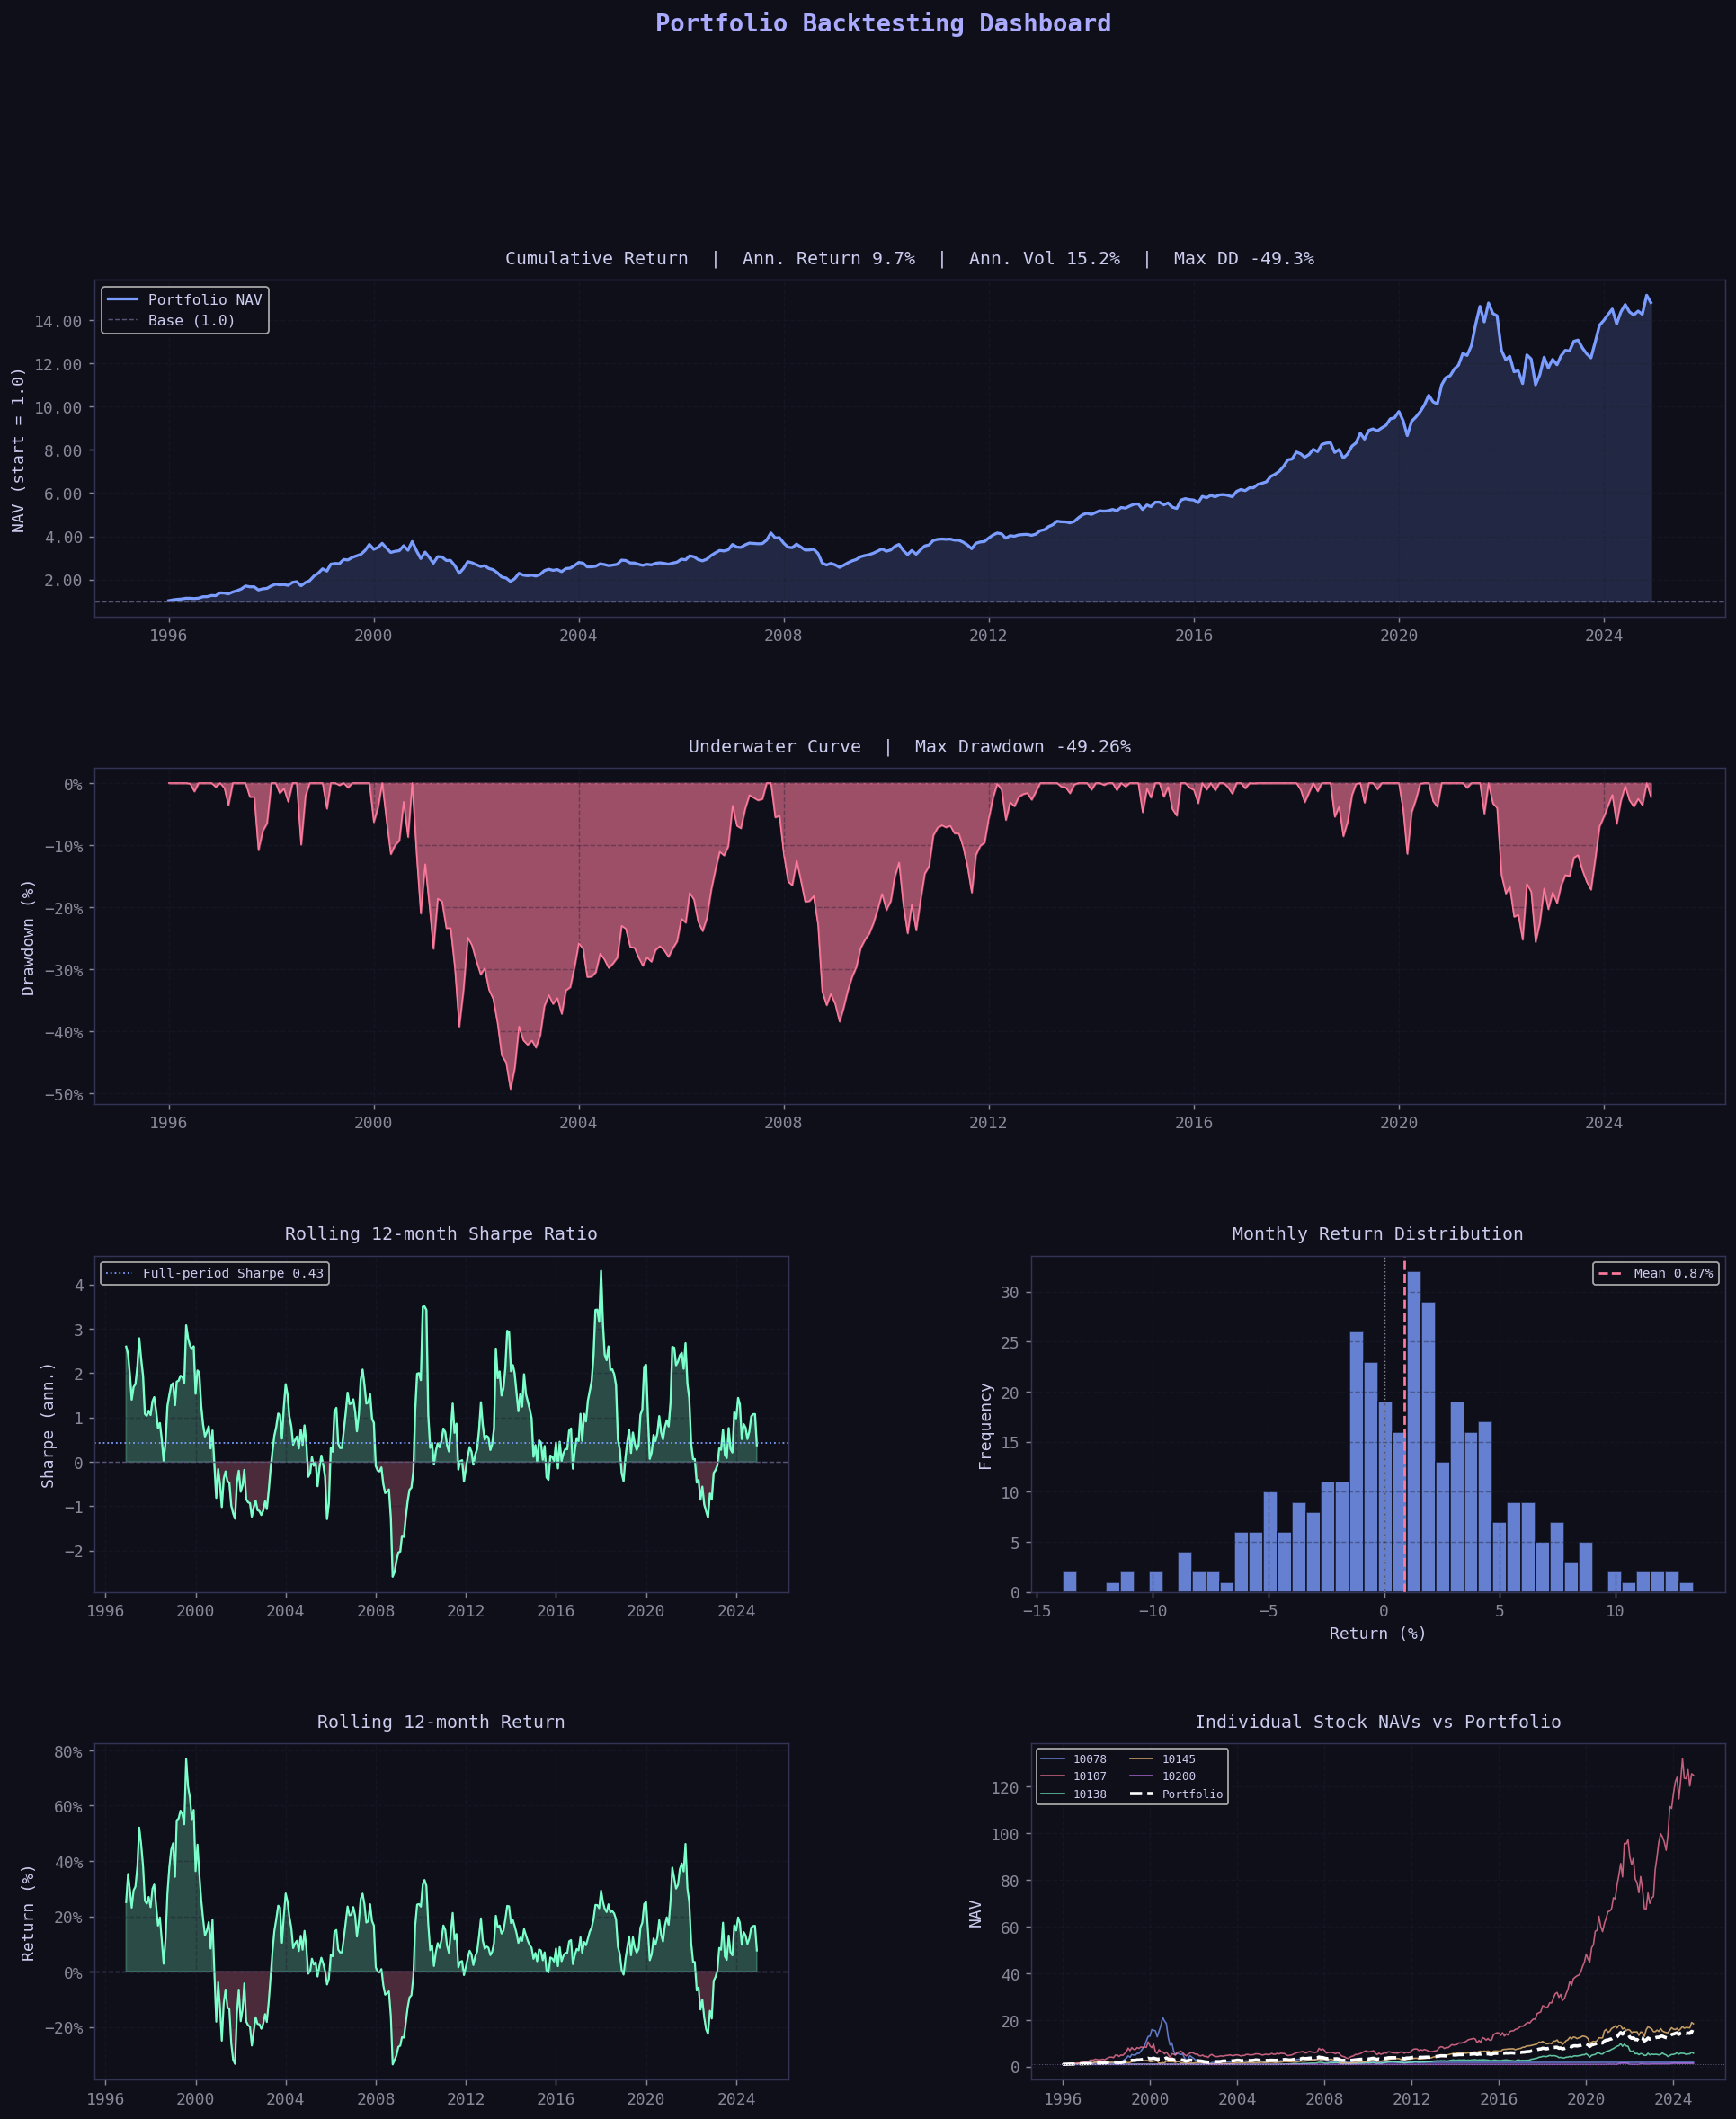

Dashboard saved to backtest_dashboard.png


In [30]:
# ── 6. Main dashboard ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 20))
fig.patch.set_facecolor('#0f0f1a')
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

dates = nav.index.to_timestamp()  # Period → Timestamp for matplotlib

# ── 6-A  Cumulative NAV ────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(dates, nav.values, 1, where=nav.values >= 1,
                 alpha=0.18, color=ACCENT[0])
ax1.fill_between(dates, nav.values, 1, where=nav.values < 1,
                 alpha=0.18, color=ACCENT[1])
ax1.plot(dates, nav.values, color=ACCENT[0], lw=1.8, label='Portfolio NAV')
ax1.axhline(1.0, color='#555577', lw=0.8, ls='--', label='Base (1.0)')
ax1.set_title(f'Cumulative Return  |  Ann. Return {ann_ret*100:.1f}%  |  '
              f'Ann. Vol {ann_vol*100:.1f}%  |  Max DD {max_dd*100:.1f}%',
              fontsize=11, pad=10)
ax1.set_ylabel('NAV (start = 1.0)')
ax1.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.4)

# ── 6-B  Drawdown ──────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
ax2.fill_between(dates, drawdown.values * 100, 0,
                 alpha=0.6, color=ACCENT[1], label='Drawdown')
ax2.plot(dates, drawdown.values * 100, color=ACCENT[1], lw=0.8)
ax2.set_title(f'Underwater Curve  |  Max Drawdown {max_dd*100:.2f}%', fontsize=11, pad=10)
ax2.set_ylabel('Drawdown (%)')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.grid(True, alpha=0.4)

# ── 6-C  Rolling 12m Sharpe ────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0])
rs_dates = roll_sharpe.dropna().index.to_timestamp()
rs_vals  = roll_sharpe.dropna().values
ax3.fill_between(rs_dates, rs_vals, 0,
                 where=rs_vals >= 0, alpha=0.25, color=ACCENT[2])
ax3.fill_between(rs_dates, rs_vals, 0,
                 where=rs_vals < 0,  alpha=0.25, color=ACCENT[1])
ax3.plot(rs_dates, rs_vals, color=ACCENT[2], lw=1.3)
ax3.axhline(0, color='#555577', lw=0.8, ls='--')
ax3.axhline(sharpe_ann, color=ACCENT[0], lw=1.0, ls=':', label=f'Full-period Sharpe {sharpe_ann:.2f}')
ax3.set_title('Rolling 12-month Sharpe Ratio', fontsize=11, pad=10)
ax3.set_ylabel('Sharpe (ann.)')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.4)

# ── 6-D  Monthly return distribution ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
bins = np.linspace(port_ret.min(), port_ret.max(), 45)
ax4.hist(port_ret.values * 100, bins=bins * 100,
         color=ACCENT[0], edgecolor='#0f0f1a', alpha=0.80)
ax4.axvline(port_ret.mean() * 100, color=ACCENT[1], lw=1.5, ls='--',
            label=f'Mean {port_ret.mean()*100:.2f}%')
ax4.axvline(0, color='#888899', lw=0.8, ls=':')
ax4.set_title('Monthly Return Distribution', fontsize=11, pad=10)
ax4.set_xlabel('Return (%)')
ax4.set_ylabel('Frequency')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.4)

# ── 6-E  Rolling 12m annualised return ────────────────────────────────────────
ax5 = fig.add_subplot(gs[3, 0])
roll_nav = (1 + port_ret).rolling(12).apply(np.prod, raw=True) - 1
rn_dates = roll_nav.dropna().index.to_timestamp()
rn_vals  = roll_nav.dropna().values * 100
ax5.fill_between(rn_dates, rn_vals, 0,
                 where=rn_vals >= 0, alpha=0.25, color=ACCENT[2])
ax5.fill_between(rn_dates, rn_vals, 0,
                 where=rn_vals < 0,  alpha=0.25, color=ACCENT[1])
ax5.plot(rn_dates, rn_vals, color=ACCENT[2], lw=1.2)
ax5.axhline(0, color='#555577', lw=0.8, ls='--')
ax5.set_title('Rolling 12-month Return', fontsize=11, pad=10)
ax5.set_ylabel('Return (%)')
ax5.yaxis.set_major_formatter(mtick.PercentFormatter())
ax5.grid(True, alpha=0.4)

# ── 6-F  Individual stock NAVs ─────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[3, 1])
for i, col in enumerate(ret_mat_filled.columns):
    stock_nav = (1 + ret_mat_filled[col]).cumprod()
    ax6.plot(stock_nav.index.to_timestamp(), stock_nav.values,
             color=ACCENT[i % 10], lw=0.9, alpha=0.75, label=str(col))
port_nav_line = nav
ax6.plot(dates, port_nav_line.values,
         color='white', lw=2.0, ls='--', label='Portfolio')
ax6.axhline(1.0, color='#555577', lw=0.6, ls=':')
ax6.set_title('Individual Stock NAVs vs Portfolio', fontsize=11, pad=10)
ax6.set_ylabel('NAV')
ax6.legend(fontsize=7, ncol=2, loc='upper left')
ax6.grid(True, alpha=0.4)

fig.suptitle('Portfolio Backtesting Dashboard', fontsize=15,
             color='#aaaaff', y=0.995, fontweight='bold')
plt.savefig('backtest_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Dashboard saved to backtest_dashboard.png')

In [31]:
# ── 7. Annual return table ──────────────────────────────────────────────────────
port_df = port_ret.to_frame('ret')
port_df['year'] = port_df.index.year

def annual_stats(g):
    r = g['ret']
    ann_r  = (1+r).prod() - 1
    vol    = r.std() * np.sqrt(12)
    exc    = r - MONTHLY_RF
    shrp   = (exc.mean() / exc.std() * np.sqrt(12)) if exc.std() > 0 else np.nan
    return pd.Series({'Ann.Return(%)': round(ann_r*100,2),
                      'Ann.Vol(%)':    round(vol*100,2),
                      'Sharpe':        round(shrp,3),
                      'Months':        len(r)})

annual_tbl = port_df.groupby('year').apply(annual_stats)
print(annual_tbl.to_string())

      Ann.Return(%)  Ann.Vol(%)  Sharpe  Months
year                                           
1996          25.08        7.27   2.601    12.0
1997          26.99       18.91   1.154    12.0
1998          44.02       20.28   1.726    12.0
1999          58.47       16.98   2.607    12.0
2000         -18.12       25.55  -0.812    12.0
2001          -6.51       31.22  -0.198    12.0
2002         -20.66       20.83  -1.196    12.0
2003          20.05       12.38   1.226    12.0
2004           8.82       12.42   0.423    12.0
2005          -2.66        6.87  -0.933    12.0
2006          20.54       11.79   1.318    12.0
2007          16.66       14.22   0.878    12.0
2008         -30.30       17.11  -2.226    12.0
2009          24.42        9.25   2.003    12.0
2010          11.46       17.84   0.473    12.0
2011          -1.27       10.62  -0.443    12.0
2012           9.08        8.75   0.588    12.0
2013          23.60        6.02   2.927    12.0
2014           8.59        4.48   0.989 

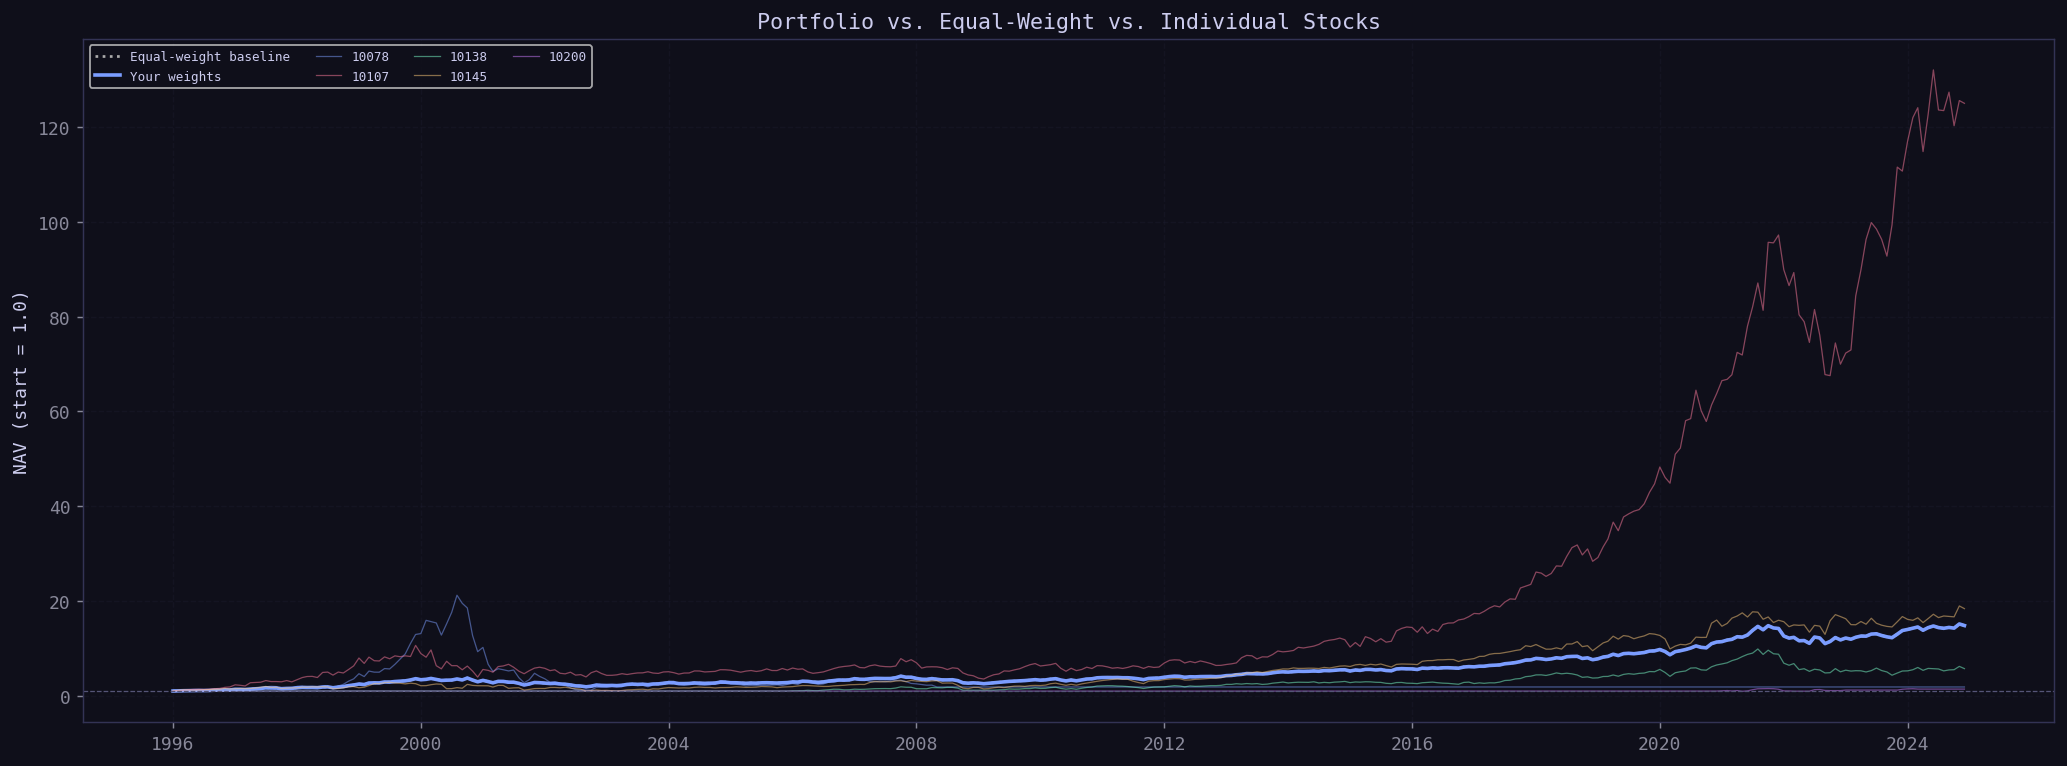

In [32]:
# ── 8. Weight sensitivity — quick sweep ────────────────────────────────────────
# Compare equal-weight vs. your custom weights vs. single-stock benchmarks

fig2, ax = plt.subplots(figsize=(16, 6))
ax.set_facecolor('#0f0f1a')

# Equal-weight baseline
n = len(SELECTED_PERMNOS)
ew_ret = ret_mat_filled @ (np.ones(n)/n)
ew_nav = (1 + ew_ret).cumprod()
ax.plot(ew_nav.index.to_timestamp(), ew_nav.values,
        color='#aaaaaa', lw=1.5, ls=':', label='Equal-weight baseline')

# Custom weights
ax.plot(dates, nav.values, color=ACCENT[0], lw=2.0, label='Your weights')

# Individual stocks (thin)
for i, col in enumerate(ret_mat_filled.columns):
    sn = (1 + ret_mat_filled[col]).cumprod()
    ax.plot(sn.index.to_timestamp(), sn.values,
            color=ACCENT[i % 10], lw=0.7, alpha=0.5, label=str(col))

ax.axhline(1.0, color='#555577', lw=0.7, ls='--')
ax.set_title('Portfolio vs. Equal-Weight vs. Individual Stocks', fontsize=12)
ax.set_ylabel('NAV (start = 1.0)')
ax.legend(fontsize=7, ncol=4, loc='upper left')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('backtest_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f1a')
plt.show()

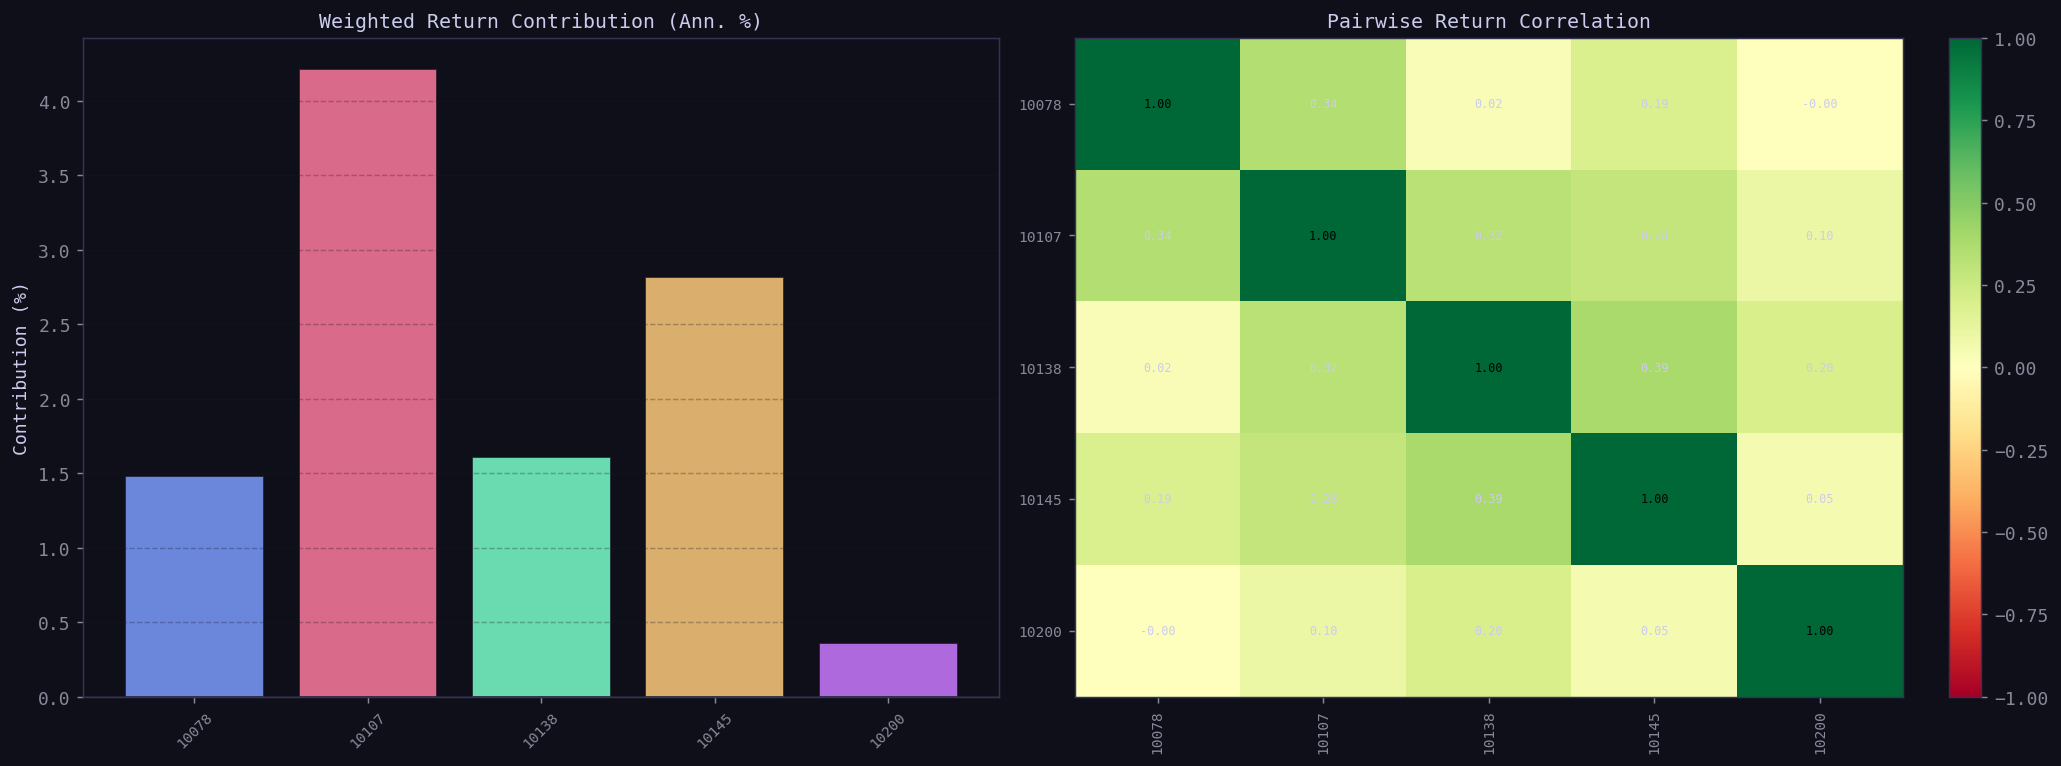

In [33]:
# ── 9. Per-stock contribution & correlation heatmap ────────────────────────────
fig3, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0f0f1a')

# 9-A  Return contribution = weight × mean monthly return (annualised)
stock_ann_ret = ret_mat_filled.mean() * 12 * 100
contributions = stock_ann_ret * WEIGHTS
ax_c = axes[0]
ax_c.set_facecolor('#0f0f1a')
bars = ax_c.bar(range(n), contributions.values,
                color=[ACCENT[i] for i in range(n)], edgecolor='#0f0f1a', alpha=0.85)
ax_c.axhline(0, color='#555577', lw=0.8)
ax_c.set_xticks(range(n))
ax_c.set_xticklabels([str(p) for p in SELECTED_PERMNOS], rotation=45, fontsize=8)
ax_c.set_title('Weighted Return Contribution (Ann. %)', fontsize=11)
ax_c.set_ylabel('Contribution (%)')
ax_c.grid(True, alpha=0.3, axis='y')

# 9-B  Return correlation heatmap
corr = ret_mat_filled.corr()
ax_h = axes[1]
ax_h.set_facecolor('#0f0f1a')
im = ax_h.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax_h.set_xticks(range(n))
ax_h.set_yticks(range(n))
ax_h.set_xticklabels([str(p) for p in SELECTED_PERMNOS], rotation=90, fontsize=8)
ax_h.set_yticklabels([str(p) for p in SELECTED_PERMNOS], fontsize=8)
for i in range(n):
    for j in range(n):
        ax_h.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                  fontsize=6.5, color='black' if abs(corr.iloc[i,j]) > 0.4 else '#ccccee')
plt.colorbar(im, ax=ax_h, fraction=0.046)
ax_h.set_title('Pairwise Return Correlation', fontsize=11)

plt.tight_layout()
plt.savefig('backtest_contrib_corr.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

what we have:

for each (stock, month, ret_1m), we have a feature vector f

so

basically
the datasets we have are:
(month, 
    stock, month, ret_1m, f)

and

for each tuple, 
we assume that, it's independent to other tuples

--> and this consitutes our dataset

am i right? 


Q: what's the number of dataset? what is a dataset? 
is a dataset of the form
(month1, 
    stock1, ret_1m, f
    stock2, ret_1m, f
    stock3, ret_1m, f
    ...
    stock50, month, ret_1m, f)
(which counts as 1 dataset)
    or
(month1, stock1, ret_1m, f) 
(month1, stock2, ret_1m, f) 
(month1, stock3, ret_1m, f) 
..
(month1, stock50, ret_1m, f) ? 
(which counts at 50 datasets)


so to train our modoel, 
our input is:

every boosting step, put in 1 group



what i observed:
x axis: ret_1m
y axis: rank score for a given month

distribution of points: normal distribution
my hypothesis: is f historically dependent (yes/no)

Case "No": **Stock-blind**
Suppose f is not historically dependent on the span of a particular stock. Then, given f, for any stock, is it more confident for us to predict the returns compared to if we know f is historically dependent on the span of a particular stock? 


when we train, are we assuming stock-blind? Yes. 


But, you just said, f is historically dependent on the span of a particular stock. ---> For each stock, is there a strong correlation between feature value vs ret_1m? Not a strong correlation. (heuristically)






yes ---> suppose 50 stocks have the same f, then do they all have the same ret_1m? don't know. 
no: 



....


anyways, we observe that, we trained the model, but the model seems not learning anything. 

so then, i suggest on exploring the historical dependency of each feature and reevaluate our pipeline



if we learn from something historically dependent, shall we predict on something that is influenced from historical tendency rather than on noise? 